In [2]:
!pip install squarify pypalettes highlight_text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Import to create custom legend patches
import matplotlib.colors as mcolors # For creating custom colormaps
import matplotlib.lines as mlines # Import the necessary module for creating Line2D objects.

In [3]:
# Load the dataset from the CSV file named "output.csv" into a pandas DataFrame.
df = pd.read_csv("output.csv")

In [4]:
# Extract the top 25 companies with the largest market capitalization.

# df.nlargest(n, columns) returns a subset with the top 'n' rows based on
# the specified column(s). Here, we use "market_cap" to determine the size.
top25 = df.nlargest(25, 'market_cap')

# Sort these 25 companies in descending order of their market capitalization.
# The first rows represent companies with the highest market cap.
top25_sorted = top25.sort_values('market_cap', ascending=False)


TREEMAP

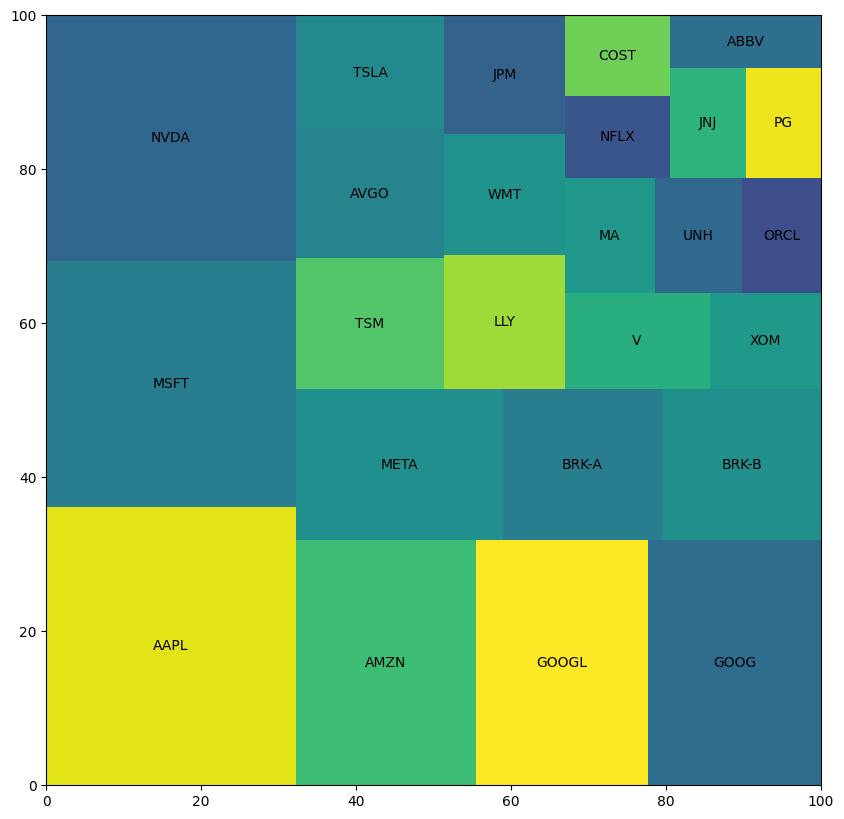

In [5]:
import squarify


# The market cap values are large numbers, so we scale them down.
scaling_factor = 1e10  # Adjust this factor if needed

# create a figure
fig, ax = plt.subplots(figsize=(10,10))


# add treemap
squarify.plot(
   sizes=top25["market_cap"]/scaling_factor,
   label=top25["symbol"],
   ax=ax
)

# display plot
plt.show()

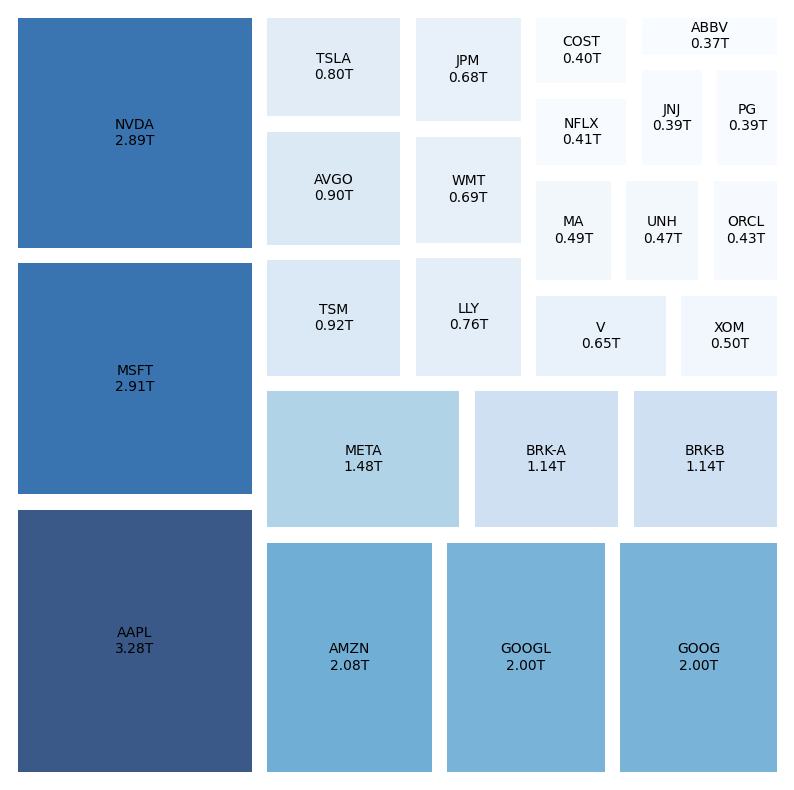

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import squarify

# Calculate scaled market capitalization
my_values = top25["market_cap"] / scaling_factor

# Create a continuous color palette using the "Blues" colormap from matplotlib.
# The colors will be mapped based on the scaled market cap values.
cmap = plt.cm.Blues  # Select the "Blues" colormap
mini = my_values.min()  # Determine the minimum scaled market cap value
maxi = my_values.max()  # Determine the maximum scaled market cap value

# Create a normalization object to map the market cap values to a range of [0, 1].
norm = matplotlib.colors.Normalize(vmin=mini, vmax=maxi)

# Apply the normalization to each value and assign a color from the colormap.
# This generates a list of colors, where lower values correspond to lighter shades
# and higher values to darker shades of blue.
colors = [cmap(norm(value)) for value in my_values]

# Generate labels that include both the company symbol and its market capitalization.
# The market cap is scaled to trillions (dividing by 1e12) and formatted to two decimal places,
# with a 'T' appended at the end to indicate trillions.
labels = [f"{sym}\n{cap/1e12:.2f}T" for sym, cap in zip(top25["symbol"], top25["market_cap"])]

# Create a figure and an axis for the plot with a size of 10x10 inches.
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()  # Remove the axis for a cleaner visualization

# Create the treemap using the squarify.plot function.
squarify.plot(
    sizes=my_values,
    label=labels,
    color=colors,
    alpha=0.8,
    pad=0.2,
    text_kwargs={'color': 'black'}
)

plt.show()

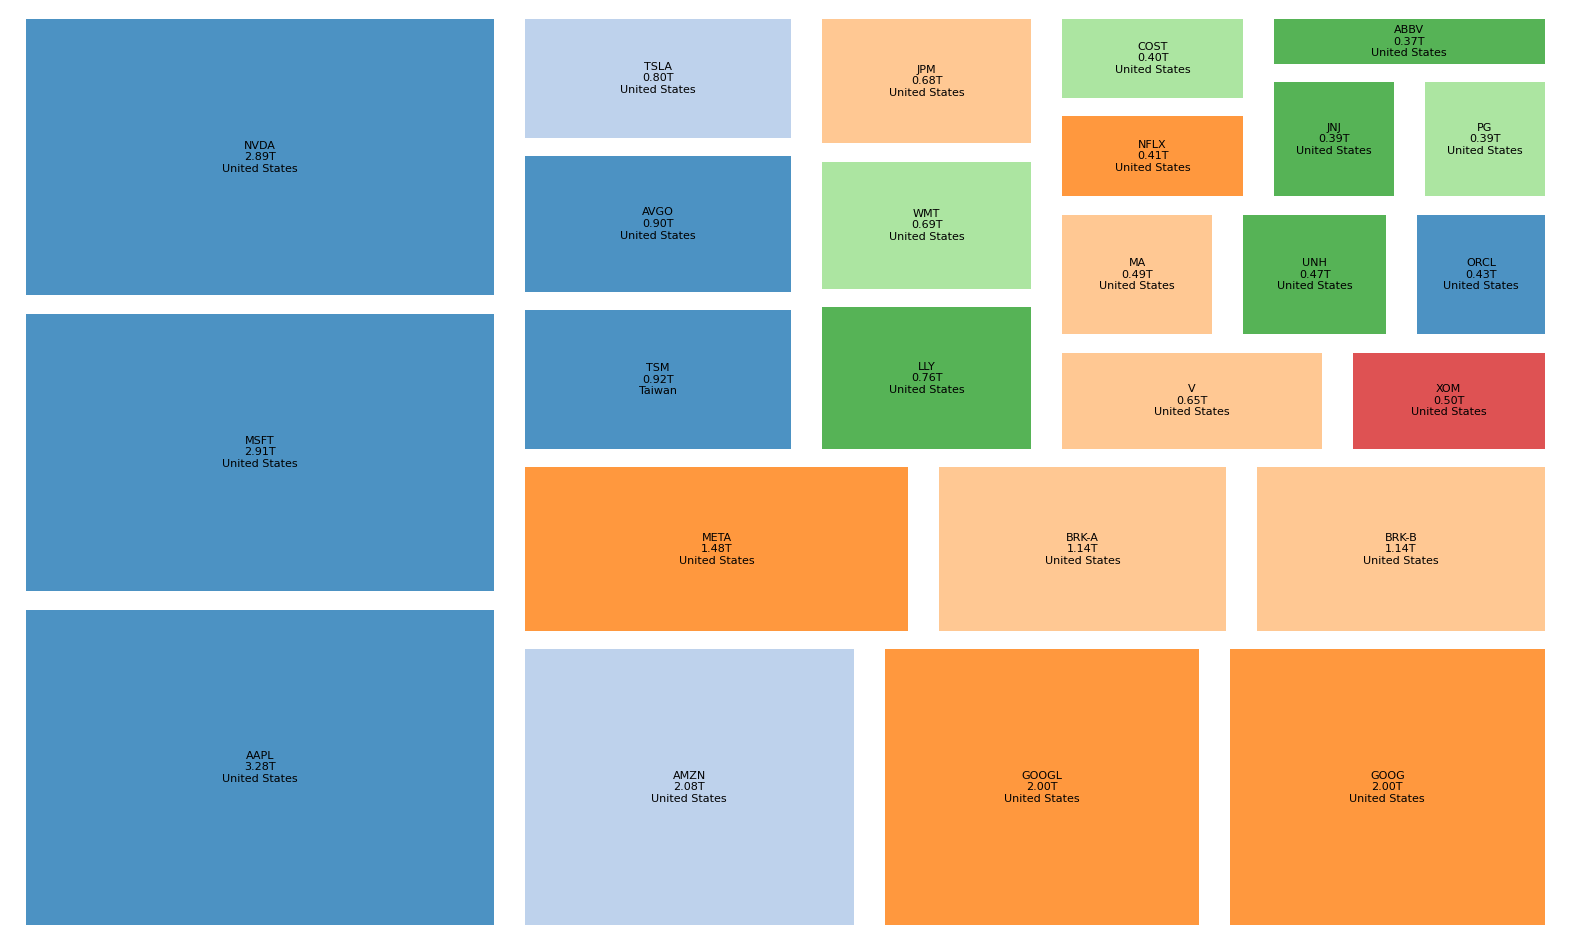

In [7]:
# Generate labels that include the company symbol, its market capitalization, and its country.
# The market cap is scaled to trillions (dividing by 1e12) and formatted to two decimal places,
# with a 'T' appended at the end to indicate trillions.
#
# Using the zip Function:
# The zip() function is used to aggregate these three columns into tuples. For each iteration, zip() produces a tuple (sym, cap, country) where:
#   • sym is the current company’s symbol.
#   • cap is its market capitalization.
#   • country is the country it belongs to.
labels = [
    f"{sym}\n{cap/1e12:.2f}T\n{country}"
    for sym, cap, country in zip(top25_sorted["symbol"], top25_sorted["market_cap"], top25_sorted["country"])
]

# --------------------------
# Color Mapping Based on Sector
# --------------------------

# Extract the unique sectors from the top 25 companies.
unique_sectors = top25_sorted['sector'].unique()

# Choose a color palette using matplotlib's 'tab20' colormap.
colors = plt.cm.tab20.colors

# Create a dictionary mapping each sector to a specific color.
# The enumerate() function assigns an index to each sector.
# Using modulo (%) with the length of the colors tuple ensures that if there are more than 20 sectors,
# the colors are reused in a cyclic fashion.
sector_color_map = {
    sector: colors[i % len(colors)]
    for i, sector in enumerate(unique_sectors)
}

# Map each company's sector to its corresponding color.
sqr_colors = top25_sorted['sector'].map(sector_color_map)

# Create a figure and an axis for the plot with a size of 10x10 inches.
fig, ax = plt.subplots(figsize=(20, 12))
ax.set_axis_off()  # Remove the axis for a cleaner visualization

# Create the treemap using the squarify.plot function.
# Parameters:
# - sizes: the scaled market cap values determining the rectangle sizes.
# - label: custom labels combining the company symbol, market cap in trillions, and country.
# - color: colors assigned based on the company's sector.
# - alpha: transparency level (0.8 means slightly transparent).
# - pad: spacing between rectangles for visual separation.
# - text_kwargs: specifies that the label text should be black.
squarify.plot(
    sizes=my_values,
    label=labels,
    color=sqr_colors,
    alpha=0.8,
    pad= 0.25,
    text_kwargs={'color': 'black','fontsize': '8'}
)


plt.show()

In [1]:
# First, in a separate cell or line, install plotly if not already installed:
# !pip install plotly

import pandas as pd
import plotly.express as px

# Load the CSV file
df = pd.read_csv('output.csv')

# Group the DataFrame by the 'country' column and count the number of rows (companies) in each group.
# This creates a Series where the index is the country and the value is the count of companies.
# Then, reset the index to convert the Series into a DataFrame, naming the count column 'ncompany'.
# The resulting DataFrame (df_group) has two columns:
# - 'country': the country name
# - 'ncompany': the number of companies in that country
df_group = df.groupby('country') \
             .size() \
             .reset_index(name='ncompany')

# Create treemap including all countries
fig_all = px.treemap(
    df_group,
    path=["country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='Blues',
    title="Treemap: Number of Companies by Country (All Countries)"
)
fig_all.show()

# Filter out the US from the grouped data
df_group_no_us = df_group[df_group['country'] != 'United States']

# Create treemap excluding the US
fig_no_us = px.treemap(
    df_group_no_us,
    path=["country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='Blues',
    title="Treemap: Number of Companies by Country (Excluding US)"
)
fig_no_us.show()

In [2]:
import pandas as pd
import plotly.express as px

# --------------------------
# 1. Load the CSV files
# --------------------------
df_output = pd.read_csv('output.csv')
df_all = pd.read_csv('all.csv')

# --------------------------
# 2. Transform country names in df_output
# --------------------------
df_output['country'] = df_output['country'].replace({
    "United States": "United States of America",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "Netherlands": "Netherlands, Kingdom of the",
    "South Korea": "Korea, Republic of",
    "Taiwan": "Taiwan, Province of China"
})

# --------------------------
# 3. Create a DataFrame with the number of companies per country
# --------------------------
df_group = df_output.groupby('country').size().reset_index(name='ncompany')

# --------------------------
# 4. Rename 'name' column to 'country' in df_all and merge with grouped data
# --------------------------
df_all.rename(columns={'name': 'country'}, inplace=True)

# Merge the grouped DataFrame (df_group) with a subset of df_all
# - df_group contains the number of companies per country (columns: 'country', 'ncompany')
# - df_all contains additional country information (including 'alpha-3' and 'region'),
#   but we only need the columns 'country', 'alpha-3', and 'region'
#
# We perform a left merge using 'country' as the key, so every row in df_group will be kept.
# If a matching country is found in the selected subset of df_all, its 'alpha-3' and 'region'
# values will be added; if no match is found, those columns will have NaN values.
df_merged = pd.merge(
    df_group,                                 # Left DataFrame: contains country and ncompany count
    df_all[['country', 'alpha-3', 'region']],   # Right DataFrame: filtered to include only needed columns
    on='country',                             # Column to merge on: common to both DataFrames
    how='left'                                # Type of join: keeps all rows from df_group (left)
)

# --------------------------
# 5. Remove rows with any NaN values from the merged DataFrame
# --------------------------
df_merged = df_merged.dropna()

# --------------------------
# 6. Create Treemaps
# --------------------------

# 6a. Treemap with all countries (using 'region' and 'country' for hierarchy)
fig_all = px.treemap(
    df_merged,
    path=["region", "country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='Blues',
    title="Treemap: Number of Companies by Country (All Countries)"
)
fig_all.show()

# 6b. Treemap excluding the US (using the transformed name for the United States)
df_merged_no_us = df_merged[df_merged['country'] != "United States of America"]
fig_no_us = px.treemap(
    df_merged_no_us,
    path=["region", "country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='Blues',
    title="Treemap: Number of Companies by Country (Excluding US)"
)
fig_no_us.show()

# --------------------------
# 7. Create a Choropleth Map for All Countries
# --------------------------
fig_choropleth = px.choropleth(
    df_merged,
    locations="alpha-3",
    color="ncompany",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Blues,
    title="Choropleth Map: Number of Companies by Country"
)
fig_choropleth.show()

# --------------------------
# 8. Create a Choropleth Map for Europe Only
# --------------------------
df_europe = df_merged[df_merged['region'] == 'Europe']
fig_choropleth_europe = px.choropleth(
    df_europe,
    locations="alpha-3",
    color="ncompany",
    color_continuous_scale=px.colors.sequential.Plasma,
    hover_name="country",
    locationmode = 'ISO-3', # set of locations match entries in `locations`
    title="Choropleth Map: Number of Companies by Country (Europe Only)"
)
fig_choropleth_europe.show()

In [3]:
# Filter for European countries
df_europe = df_merged[df_merged['region'] == 'Europe']

# Create the choropleth map with customized hover data
fig_choropleth_europe = px.choropleth(
    df_europe,
    locations="alpha-3",         # ISO-3 codes used to locate each country
    color="ncompany",            # Color intensity based on the number of companies
    hover_name="country",        # Display country name on hover
    # Instead of using hover_data to include region, use custom_data to ensure order and type:
    custom_data=["region", "country"],
    locationmode='ISO-3',        # Matching ISO-3 codes with map data
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={'ncompany': 'Number of Companies'},
    title="Choropleth Map: Number of Companies by Country (Europe Only)"
)

# Highlight borders for better clarity
fig_choropleth_europe.update_traces(marker_line_color='black', marker_line_width=1.5)

# Custom Hover Template:
# • %{hovertext} displays the country name (set via the hover_name parameter).
# • %{z} shows the value for "ncompany".
# • %{customdata[0]} refers to the first (and only) item in the custom data array, which is the "region" string.
# • <extra></extra> suppresses the default trace info box.
fig_choropleth_europe.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "Companies: %{z}<br>" +
                  "Region: %{customdata[0]}<br>"+
                  "addText: %{customdata[1]}<extra></extra>"
)
fig_choropleth_europe.show()


In [4]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --------------------------
# 1. Load the CSV files
# --------------------------
df_output = pd.read_csv('output.csv')
df_all = pd.read_csv('all.csv')

# --------------------------
# 2. Transform country names in df_output
# --------------------------
df_output['country'] = df_output['country'].replace({
    "United States": "United States of America",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "Netherlands": "Netherlands, Kingdom of the",
    "South Korea": "Korea, Republic of",
    "Taiwan": "Taiwan, Province of China"
})

# --------------------------
# 3. Create a DataFrame with the number of companies per country
# --------------------------
df_group = df_output.groupby('country').size().reset_index(name='ncompany')

# --------------------------
# 4. Rename 'name' column to 'country' in df_all and merge with grouped data
# --------------------------
df_all.rename(columns={'name': 'country'}, inplace=True)
df_merged = pd.merge(df_group, df_all[['country', 'alpha-3', 'region']], on='country', how='left')

# --------------------------
# 5. Remove rows with any NaN values from the merged DataFrame
# --------------------------
df_merged = df_merged.dropna()
#print(df_merged)

# --------------------------
# 6. Create Treemaps
# --------------------------

# 6a. Treemap with all countries (using 'region' and 'country' for hierarchy)
fig_all = px.treemap(
    df_merged,
    path=["region", "country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='RdBu',
    title="Treemap: Number of Companies by Country (All Countries)"
)

# 6b. Treemap excluding the US (using the transformed name for the United States)
df_merged_no_us = df_merged[df_merged['country'] != "United States of America"]
fig_no_us = px.treemap(
    df_merged_no_us,
    path=["region", "country"],
    values="ncompany",
    color="ncompany",
    color_continuous_scale='RdBu',
    title="Treemap: Number of Companies by Country (Excluding US)"
)

# --------------------------
# 7. Create a Choropleth Map for All Countries
# --------------------------
fig_choropleth = px.choropleth(
    df_merged,
    locations="alpha-3",
    color="ncompany",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.RdBu, #https://plotly.com/python/builtin-colorscales/
    title="Choropleth Map: Number of Companies by Country"
)

# --------------------------
# 8. Combine the figures using a grid-like layout
# --------------------------
# Create a subplot figure with 2 rows and 2 columns using make_subplots.
fig = make_subplots(
    rows=2, cols=2,  # Define a grid with 2 rows and 2 columns
    specs=[
        # The 'specs' parameter defines the type and structure for each cell in the grid.
        # For the first row, we set both cells to be of type "treemap":
        [{"type": "treemap"}, {"type": "treemap"}],
        # For the second row, we want a single choropleth map that spans both columns.
        # "colspan": 2 indicates that the first cell in the second row should span 2 columns.
        # The second cell is set to None because it's merged with the first cell.
        [{"colspan": 2, "type": "choropleth"}, None]
    ],
    subplot_titles=(
        "Treemap: All Countries",    # Title for the first cell (top left)
        "Treemap: Excluding US",       # Title for the second cell (top right)
        "Choropleth Map: Number of Companies by Country"  # Title for the bottom row spanning both columns
    )
)

# Add traces from the first treemap to row 1, col 1
for trace in fig_all.data:
    fig.add_trace(trace, row=1, col=1)

# Add traces from the second treemap to row 1, col 2
for trace in fig_no_us.data:
    fig.add_trace(trace, row=1, col=2)

# Add traces from the choropleth map to row 2, col 1 (spanning both columns)
for trace in fig_choropleth.data:
    fig.add_trace(trace, row=2, col=1)

# Update the layout for overall title and dimensions
fig.update_layout(
    height=900,
    width=1200,
    title_text="Company Distribution Visualization"
)

fig.show()